# Lab 079 · A decision guide with reproducible evidence

**Core deliverable: your one-page essay.** Optional executable route: audit the complete corrected L060 v2 predictions, then apply a synthetic constrained-selection rule. No training or new paper reproduction. The complete compressed input is embedded below so the notebook does not depend on an unpublished repository checkout.

### PROVIDED · standalone environment

Only analysis dependencies are needed. On Colab the cell installs the exact author-observed versions. Locally use `requirements-l079-observed.txt`. Live Colab remains NOT_CHECKED. No model weights or remote dataset downloads are required.

In [ ]:
# @colab-bootstrap — standalone L079 analysis; no repository clone
import sys, subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','numpy==2.5.0','pandas==3.0.3','scipy==1.18.0'])
print('Analysis environment:',sys.version)

## Start cold · choose before reading



A fraud table has 6,000 labeled transactions, merchant IDs, a text description and timestamps. Predictions must serve next month's traffic within 5 ms per request. Write down your first baseline, validation split, strongest challenger and one result that would change your mind. **Commit to four sentences before reading on.** A model name without a split is not yet a decision.

**Today's win:** write a one-page decision guide that another researcher can execute and challenge. Spend about 20 minutes on sections 1–4, then 20 minutes on the writing task. The optional audit notebook rebuilds every displayed rank from the complete corrected Lesson 60 predictions. It does not train new models.



## 1 · The missing step between knowing models and choosing one

[Lesson 77](../lessons/0077-single-table-ceiling.html) showed an information ceiling: a better learner cannot recover information discarded by its input. [Lesson 78](../lessons/0078-message-passing-preview.html) supplied a mechanism for bringing in neighboring information. Neither result says that a GNN should be your first baseline. You still need to establish that the extra information is available at prediction time, useful beyond simple aggregates, and worth its cost.

The same logic applies within single-table learning. Choose in this order: **available information → deployment-matching split → feasible candidates → validation comparison → locked test evaluation**. A *regime* is the combination of task, sample size, feature types, availability, shift and resource constraints. A *shortlist* is a set of hypotheses to test, not a prediction of a universal winner.

For the fraud example, define one prediction per transaction at arrival. Build merchant aggregates only from events and labels already available then. Use earlier periods for training and later periods for validation/test, allowing the fraud-label delay. If production includes unseen merchants, report that subgroup separately; a group split is useful for that question but does not replace chronological evaluation. Measure p95 latency on the intended hardware, batch size, context size and complete preprocessing path.

<figure class="dg-figure">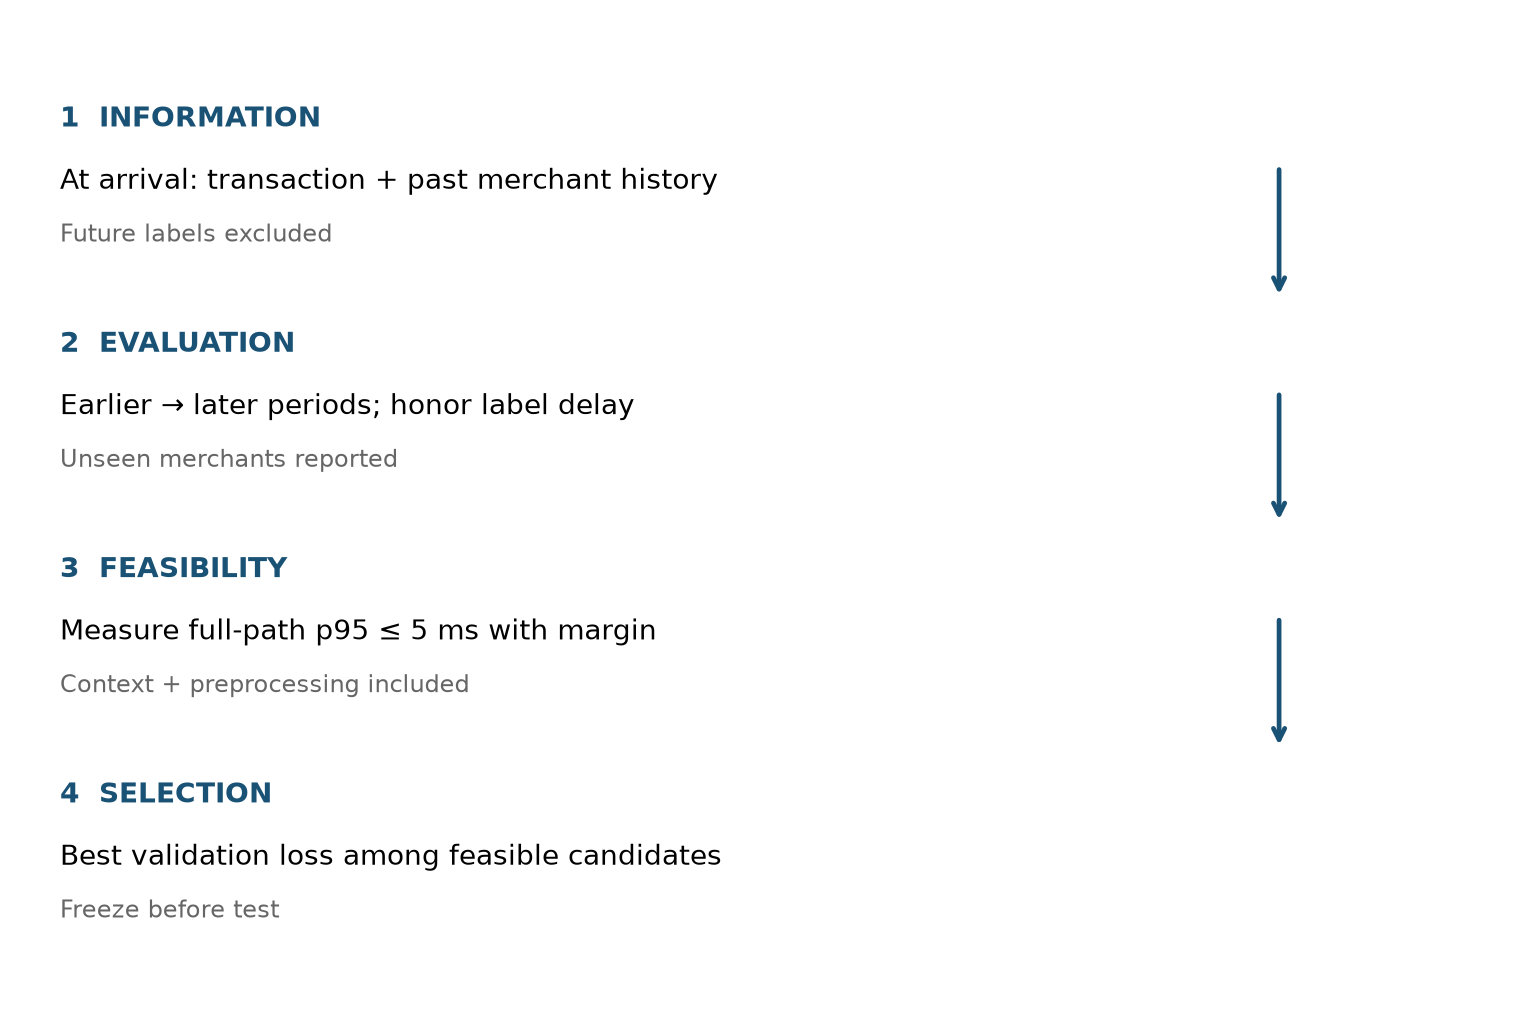<figcaption>Worked fraud case: information eligibility precedes evaluation, measured feasibility and validation-only selection. Each gate carries a concrete requirement.</figcaption></figure>



## 2 · A decision table, with reasons and falsifiers

This is a guide to the **historical model versions studied in Year 2**, not a September 2026 leaderboard. Pin the exact implementation and checkpoint before testing. Row-count thresholds are feasibility prompts, not scientific phase transitions. The paper sources support the mechanisms; the candidate order below is our operational judgment.

| Regime | Start and challenge | Why this is a useful test | What would change the decision? |
|---|---|---|---|
| Ordinary mixed numeric/categorical table | Tuned GBDT; challenge with RealMLP and TabM | Tree partitions are a strong baseline for heterogeneous features; strong MLP recipes and efficient ensembles deserve a fair comparison | A neural candidate improves the prespecified validation metric within the serving budget |
| Few labels; checkpoint fits task and memory | GBDT plus historical TabPFN v2; TabICL 2025 for supported classification | In-context inference reuses a learned prior without fitting fresh weights for each task | Chronological validation, calibration or end-to-end inference cost removes the apparent advantage |
| More rows or larger context | Trees/TabM; feasibility-test the pinned TabICL classification model | Full-context ICL and gradient-trained predictors incur different memory and prediction costs | Measured batching/context cost or validation performance changes the feasible set |
| A plausible feature-interaction hypothesis | Keep trees/MLPs; add FT-Transformer | Feature-token attention offers a distinct mixing mechanism | Its gain disappears under equal selection budget or a simpler model matches it |
| High-cardinality categories or unseen IDs | CatBoost with its native categorical route; compare a training-fitted vocabulary/embedding route | Identity reuse and unseen-category behavior matter more than a nominal model family | Group/cold-start evaluation exposes memorization; larger embeddings do not rescue it |
| Informative names or free text | Compare no-text, simple text features and an explicitly pinned semantic encoder; consider CARTE for suitable cross-table transfer | Text representation changes the information interface and the cost | A frozen text ablation shows no value, or text was unavailable at the cutoff |
| Complementary validation errors; enough serving budget | Out-of-fold blend/stack of retained families | Diversity may improve predictions; every selection step must stay out of held-out folds | Honest OOF comparison and a locked holdout fail to beat the best feasible single model |
| Relevant history or neighbors absent from the row | First add point-in-time aggregates; then compare a relational model | Test access to additional information before crediting a graph architecture | Matched aggregates erase the gain, or any neighbor path leaks future information |

Read the mechanism evidence: [trees, §5](https://arxiv.org/abs/2207.08815), [RealMLP](https://arxiv.org/abs/2407.04491), [TabM](https://arxiv.org/abs/2410.24210v3), [FT-Transformer](https://arxiv.org/abs/2106.11959), [TabPFN v2](https://www.nature.com/articles/s41586-024-08328-6), and [TabICL 2025](https://arxiv.org/abs/2502.05564v2). The original TabICL paper is a classification study: do not silently apply later regression support to that historical checkpoint.

**Mechanisms are not slogans.** RealMLP is an MLP plus a carefully designed training recipe. TabM trains multiple predictions using shared parameters and averages them for inference. FT-Transformer mixes feature tokens through attention. TabPFN/TabICL use labeled training rows as inference context; “no task-specific gradient fitting” does not mean “no prediction cost.” An external ensemble combines separately obtained predictions and adds their serving requirements. Explain the particular mechanism that makes your challenger worth measuring.



## 3 · Evidence cannot travel farther than its protocol

The corrected [Lesson 60 comparison](../lessons/0060-broad-model-comparison.html) has 210 selected runs: 14 dataset/regime cells × five methods × three initialization seeds. It uses small training caps, two candidates per method and compressed neural training. Its RealMLP-TD-S and TabM-mini arms are reduced recipes. CatBoost receives common one-hot inputs. FT-Transformer, TabPFN and TabICL are **absent**. A blank cell for these families means **not measured**, not “worse.”

Reconstruct each saved loss from targets and predictions, verify split IDs and validation-only candidate selection, then average the three seed errors within each dataset. Rank the five means within that dataset; average those ranks with equal dataset weight. Low rank is good. Never pool log loss with RMSE or treat three seeds as three new datasets.

**Worked tie.** Dataset A has seed-mean errors `[.20,.20,.50]`, giving ranks `[1.5,1.5,3]`. Dataset B has `[20,10,30]`, giving `[2,1,3]`. Their equal-weight mean ranks are `[1.75,1.25,3]`. The large numerical scale of B does not give it more votes. Ranking loses effect-size information, so inspect within-dataset losses too.

**Fresh author reanalysis of frozen predictions; not new training.**

| Method | Random (11) | Matched random (3) | Temporal (3) |
|---|---:|---:|---:|
| XGBoost | 2.909 | 3.000 | 3.667 |
| CatBoost | 1.818 | 1.000 | 2.667 |
| MLP | 4.182 | 4.667 | 3.000 |
| RealMLP-TD-S | 2.909 | 2.333 | 3.667 |
| TabM-mini | 3.182 | 4.000 | 2.000 |


<figure class="dg-figure">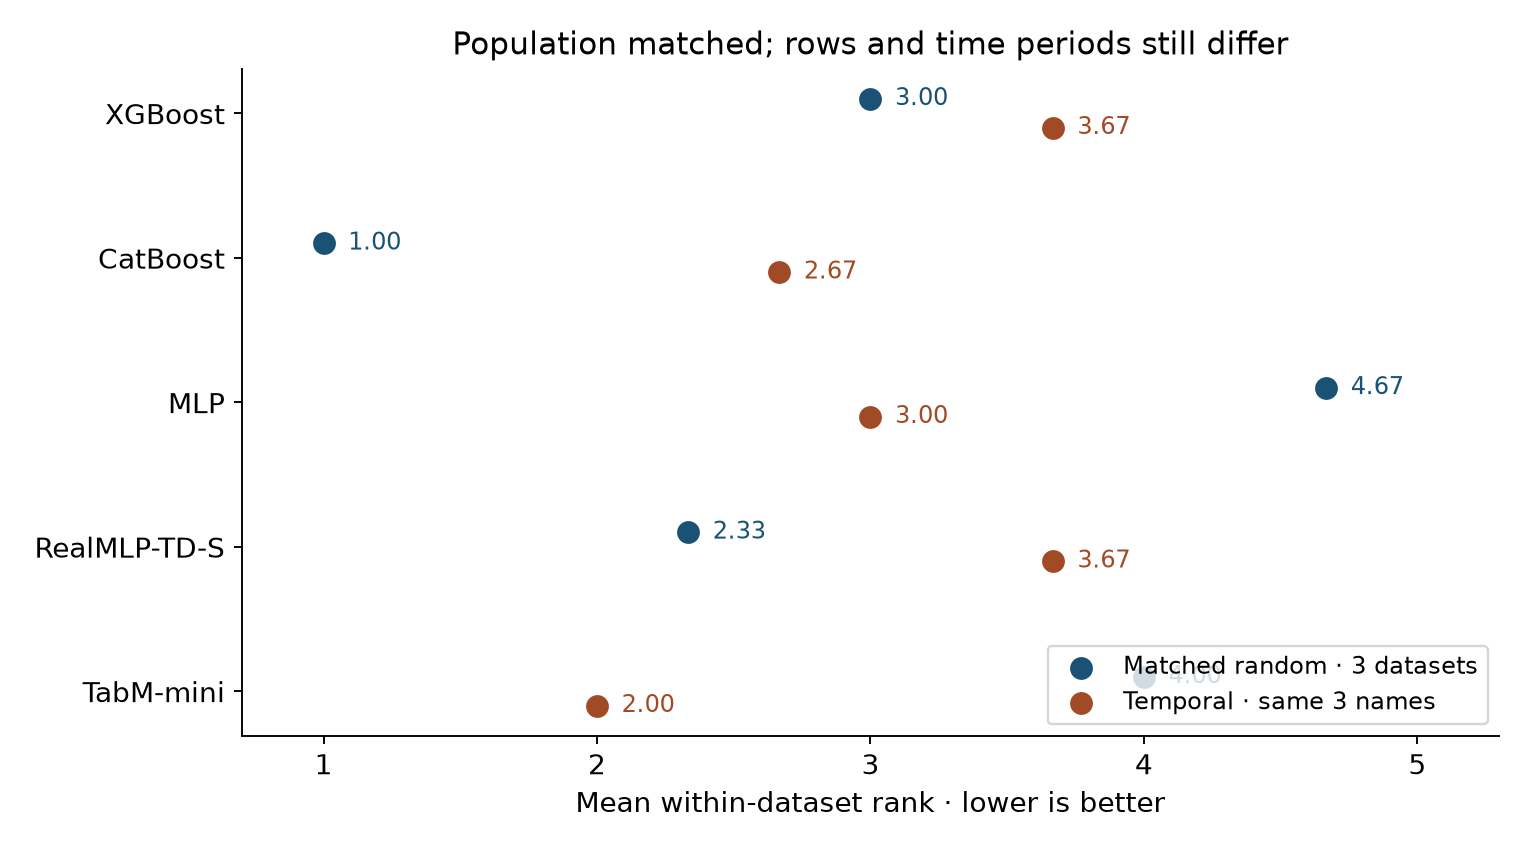<figcaption>Reanalysis of corrected L060 v2 predictions: seed means ranked within each of the same three underlying datasets, then averaged. No causal interpretation or fresh training.</figcaption></figure>



The random panel contains eleven datasets; the temporal panel contains three. Restrict random results to those same three names before interpreting the difference. Even then, these are separately sampled train/test populations, not an isolated intervention on chronology. A matched rank reversal is a reason to test the deployment split, not a causal estimate of time's effect or a universal ordering.

The notebook preserves per-dataset seed values, sample SD and ranks. Its inherited Friedman/Nemenyi summaries are exploratory, especially with only three temporal blocks; their presence does not establish equivalence or significance for a hand-picked pair. Seed variation is conditional on fixed rows. Repeating seeds cannot establish uncertainty over new business domains.

**Reproduction boundary.** We freshly audit all 210 frozen prediction records here. No predictive models are retrained in this unit; no paper benchmark is newly reproduced. The [reproduction contract](../labs/l079-reproduction.md) gives exact analysis commands, the full local training rerun command, and links to the original experiment contracts. A deterministic reanalysis is a reproducible artifact, not a replacement for full paper training.



## 4 · Make the recommendation executable

Here is a **synthetic decision example**, not measured model performance. The validation log losses are Trees .32, TabM .29 and ICL .27. Their measured-in-the-example p95 latencies are 2, 8 and 35 ms. All other constraints are assumed satisfied. Predict the choice under a 5 ms budget before moving the control.



<figure class="dg-figure">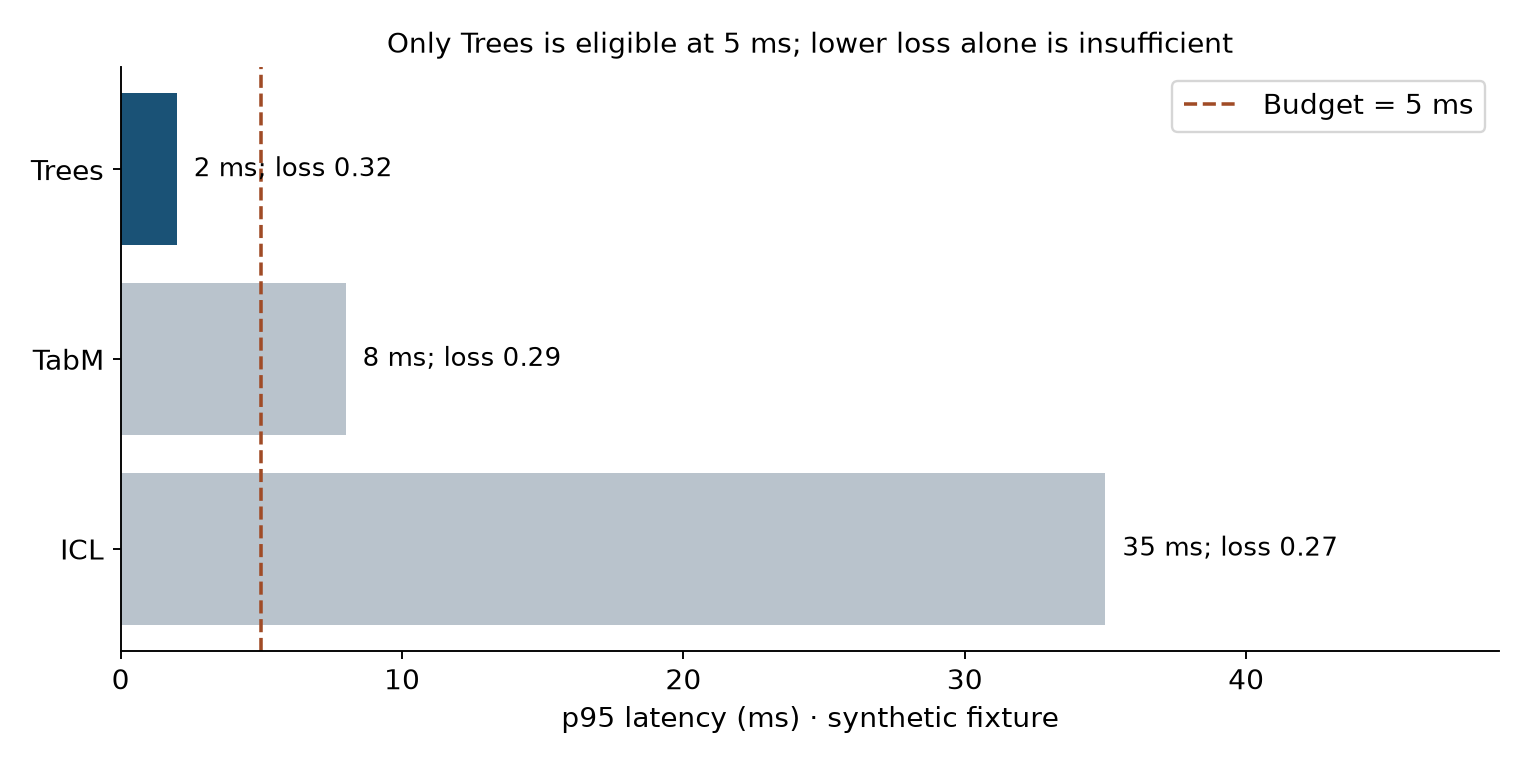<figcaption>Synthetic fixture: the 5 ms constraint excludes TabM and ICL despite lower validation losses. These are illustrative latencies, not measured model comparisons.</figcaption></figure>

At 5 ms only Trees qualifies. At 10 ms TabM becomes the lowest-loss feasible candidate; at 40 ms ICL does. Under 2 ms none qualifies. The decision rule is: filter by the declared constraint, then minimize validation loss, with a prespecified tie rule. Real latency is a measured distribution, so include a margin and repeat measurements near a threshold. The synthetic fixture uses exact point estimates to expose the logic.

The test set has no role in that rule. Once a family, preprocessing recipe and ensemble are chosen, freeze them before the final evaluation. If you inspect test results and redesign the shortlist, the old test has become development evidence; acquire a new holdout or report the adaptive nature of the evaluation. Revisit [validation overfitting](../lessons/0059-validation-set-overfitting.html) and [OOF ensembling](../lessons/0057-cross-family-ensembling.html).



## 5 · Write the one-page artifact

Download the [blank decision guide](../labs/l079-decision-template.md). Fill six to eight rows, at most about 650 words. Each row must name a regime, baseline, challenger, split/metric, resource limit, evidence source and a result that would change your mind. Include all Year 2 families across the table. Add a short worked recommendation for the opening fraud case, and a reproduction footer recording source revisions, data/split identities, seeds, environment and unrun work.

**CHECK yourself on an unfamiliar case.** A 120,000-row regression dataset has repeated customers and daily targets. Someone recommends “TabICL because it handles large tables.” Identify three missing premises before accepting the claim.

<details><summary>Feedback · reveal after answering</summary><p>The historical 2025 TabICL paper studies classification; task support must match the pinned checkpoint. Daily targets and repeated customers require a deployment-specific temporal/entity protocol. Actual memory, context size and serving cost must be measured. Also ask whether past targets and text are available at the cutoff. Row count alone cannot settle the choice.</p></details>

**Rubric: 12 points.** Award 0–2 each for deployment/split precision, mechanism-based shortlist, evidence with scope, feasible costs, falsifiable change criteria, and a complete reproduction footer. Two means concrete enough to execute; one means partially specified; zero means missing. A passing rehearsal is at least 10/12, with no test-based selection, future-information leakage or invented paper-reproduction claim. This is self-assessment until your written artifact is reviewed.

The optional notebook has two live TODOs: constrained validation selection and matching dataset populations. Its CHECK cells test your definitions; the audit runs those same functions. Submit the guide, the audit output if attempted, and your four initial sentences. A [worked guide](../solutions/l079-example-guide.md) is available **after your own draft**; different defensible shortlists are welcome.



Tomorrow, reconstruct the choice order and one counterexample without reopening the table. Before Lesson 80, explain why a model can have the best benchmark rank yet be excluded from your deployment. Ask the agent follow-up questions and bring your draft for a strict evidence review. Creating this lesson does not mark the exit exam—or this essay—complete.

**Primary reading:** [TabM, abstract and comparative experiments](https://arxiv.org/abs/2410.24210v3). Use its distinction between architectural complexity and measured performance-efficiency to challenge one row of your guide. Then read the primary paper linked in the row you find least certain.


## PROVIDED · analysis imports

The toy scenario has lower-is-better validation loss and complete-path p95 latency. Python input order is the declared tie breaker.

In [ ]:
import math, json, gzip, base64, hashlib, platform
from pathlib import Path
import numpy as np
import pandas as pd
import scipy

## TODO · select_feasible

Validate a finite nonnegative budget and finite nonnegative losses/latencies; reject duplicate names. Filter candidates at or below the budget, then return the name with minimum validation loss. Preserve input order on exact ties; return None when none qualifies. Ignore any test-loss field.

In [ ]:
def select_feasible(candidates, latency_budget_ms):
    raise NotImplementedError("Implement select_feasible")

In [ ]:
# CHECK — your live function
candidates=[dict(model='Trees',validation_loss=.32,p95_ms=2),dict(model='TabM',validation_loss=.29,p95_ms=8),dict(model='ICL',validation_loss=.27,p95_ms=35)]
assert [select_feasible(candidates,b) for b in [1,5,10,40]]==[None,'Trees','TabM','ICL']
assert select_feasible([dict(model='A',validation_loss=.2,p95_ms=2),dict(model='B',validation_loss=.2,p95_ms=1)],2)=='A'
changed=[dict(r,test_loss=i*10) for i,r in enumerate(candidates)]
assert select_feasible(changed,40)=='ICL', 'Test losses must not select candidates'
try: select_feasible(candidates,float('nan'))
except ValueError: pass
else: raise AssertionError('Reject invalid budgets')
print('CHECK: feasible set, minimum validation loss, tie rule and test isolation pass')

## TODO · matched_datasets

Require random and temporal panels with unique dataset/regime IDs. Intersect the underlying dataset names, sort them, and return both panels restricted to those names. Reject an empty intersection or malformed regime suffix.

In [ ]:
def matched_datasets(panels):
    raise NotImplementedError("Implement matched_datasets")

In [ ]:
# CHECK — your live function
fixture={'random':['A/random','B/random','C/random'],'temporal':['C/temporal','A/temporal']}
assert matched_datasets(fixture)=={'random':['A/random','C/random'],'temporal':['A/temporal','C/temporal']}
try: matched_datasets({'random':['A/random'],'temporal':['B/temporal']})
except ValueError: pass
else: raise AssertionError('Do not invent paired data')
print('CHECK: matched underlying identities, deterministic order, empty intersection pass')

## PROVIDED · full frozen evidence

All 210 records include saved targets, predictions, row IDs, candidate validation losses, selected indices and timings. This is Tier A/B evidence from L060, not newly sampled data. Check compressed and uncompressed hashes before parsing. The SHA256 pins bytes; the following audit checks their internal consistency. It cannot prove an unobserved historical training process was leakage-free.

In [ ]:
manifest={'lesson': 79, 'accessed': '2026-09-19', 'source_course_commit': 'fb4dcf9c78bba6d2bd8eb2cefd91b60c6f89caa2', 'evidence_origin': 'labs/_verify_l060_v2_results.json', 'evidence_sha256': '99387c9ac29f941ec17ad1a9593a57c780551db6371c458db9197d5eab73f266', 'local_sha256': {'data/l079/l060-v2.json.gz': 'a12ae97bc987985495ad24b270c2cd6fe24cfb876b72cff20504303762d9ea8c', 'relkit/comparison_l060.py': 'a7311a178868c308d75ea0fc7996e414f226ce5217f1df9714dd601eec76b326', 'relkit/decision_guide.py': 'cf877483280e09805d4d75a33ebee26ddf89228dc960a28dd4af4ae6cafb8758', '_verify_l079.py': '07a7b2ea3e7fafc1b53b66d80bffce266bdc33f3f1e0c6d851162d9963be5bb7'}, 'primary_sources': {'trees': 'https://arxiv.org/abs/2207.08815', 'FT-Transformer': 'https://arxiv.org/abs/2106.11959', 'RealMLP': 'https://arxiv.org/abs/2407.04491', 'TabM': 'https://arxiv.org/abs/2410.24210v3', 'TabPFN_v2': 'https://www.nature.com/articles/s41586-024-08328-6', 'TabICL_2025': 'https://arxiv.org/abs/2502.05564v2'}, 'scope': 'Historical Year 2 methods; not a September 2026 leaderboard. Complete corrected local prediction audit; published experiments not rerun.'}
compressed=base64.b64decode('...')
assert hashlib.sha256(compressed).hexdigest()==manifest["local_sha256"]["data/l079/l060-v2.json.gz"]
raw=gzip.decompress(compressed)
assert hashlib.sha256(raw).hexdigest()==manifest["evidence_sha256"]
evidence=json.loads(raw)
print(len(evidence["records"]),"complete frozen prediction records")

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t

### PROVIDED · validate_partitions

Reject overlapping or duplicate train/validation/test IDs.

In [ ]:
def validate_partitions(ids):
    if set(ids) != {'train','val','test'}:
        raise ValueError('Require exactly train, val, test')
    arrays=[np.asarray(ids[s]) for s in ['train','val','test']]
    if any(a.ndim!=1 or not len(a) or not np.issubdtype(a.dtype,np.integer) for a in arrays):
        raise ValueError('Require nonempty one-dimensional integer row IDs')
    joined=np.concatenate(arrays)
    if len(np.unique(joined))!=len(joined):
        raise ValueError('Duplicate row within or across partitions')
    return True

### PROVIDED · choose_validation

Reconstruct the declared first-minimum validation selection.

In [ ]:
def choose_validation(errors):
    errors=np.asarray(errors,float)
    if errors.ndim!=1 or not errors.size or not np.isfinite(errors).all():
        raise ValueError('Require finite nonempty validation errors')
    return int(np.argmin(errors))

### PROVIDED · score_predictions

Recompute binary log loss or regression RMSE from saved predictions.

In [ ]:
def score_predictions(y,p,regression):
    y,p=np.asarray(y,float),np.asarray(p,float)
    if y.ndim!=1 or p.shape!=y.shape or not y.size or not np.isfinite(y).all() or not np.isfinite(p).all():
        raise ValueError('Require aligned finite nonempty vectors')
    if not isinstance(regression,(bool,np.bool_)):raise ValueError('Declare regression explicitly')
    if regression:return float(np.sqrt(np.mean((y-p)**2)))
    if not np.isin(y,[0,1]).all() or np.any((p<0)|(p>1)):
        raise ValueError('Binary labels and P(y=1) in [0,1] required')
    p=np.clip(p,np.finfo(np.float64).eps,1-np.finfo(np.float64).eps)
    return float(-np.mean(y*np.log(p)+(1-y)*np.log1p(-p)))

### PROVIDED · aggregate_panel

Require the exact dataset × arm × seed design; average seeds before dataset ranks. Conditional seed SD and exploratory rank tests remain separate.

In [ ]:
def aggregate_panel(records,datasets,arms,seeds):
    """Explicit expected design detects even an entirely absent dataset or arm."""
    if not records or any(not len(v) or len(set(v))!=len(v) for v in [datasets,arms,seeds]):
        raise ValueError('Declare unique nonempty datasets, arms and seeds')
    f=pd.DataFrame(records)
    key=['dataset','arm','seed']
    if not set(key+['error','seconds']).issubset(f.columns) or f.duplicated(key).any():
        raise ValueError('Missing fields or duplicated result')
    expected=pd.MultiIndex.from_product([datasets,arms,seeds],names=key)
    indexed=f.set_index(key)
    if set(indexed.index)!=set(expected):raise ValueError('Incomplete or unexpected crossed panel')
    if not np.isfinite(f[['error','seconds']].to_numpy(float)).all() or (f.seconds<0).any():
        raise ValueError('Require finite error and nonnegative recorded cost')
    table=indexed.error.groupby(['dataset','arm']).mean().unstack('arm').reindex(index=datasets,columns=arms)
    ranks=np.stack([rankdata(row,method='average') for row in table.to_numpy()])
    n,k=ranks.shape
    p=float(friedmanchisquare(*table.to_numpy().T).pvalue) if n>=3 and k>=3 and np.any(np.ptp(ranks,axis=1)) else None
    cd=float(studentized_range.ppf(.95,k,np.inf)*np.sqrt(k*(k+1)/(12*n))) if k>1 else None
    details=[]
    for d in datasets:
        for a in arms:
            g=indexed.loc[(d,a)].reindex(seeds);v=g.error.to_numpy();sd=float(v.std(ddof=1)) if len(v)>1 else None
            half=float(t.ppf(.975,len(v)-1)*sd/np.sqrt(len(v))) if sd is not None else None
            details.append(dict(dataset=d,arm=a,mean=float(v.mean()),sd=sd,seed_values=v.tolist(),conditional_t95=None if half is None else [float(v.mean()-half),float(v.mean()+half)],seconds=float(g.seconds.sum())))
    return dict(datasets=n,seeds=list(seeds),arms=list(arms),details=details,mean_ranks=dict(zip(arms,ranks.mean(0).tolist())),dataset_ranks=dict(zip(datasets,ranks.tolist())),friedman_p=p,nemenyi_cd=cd,uncertainty='Conditional model-seed variation; dataset is the ranking block')

### PROVIDED · paired_effect

Retained canonical helper for a same-dataset paired seed difference; does not combine incompatible metrics.

In [ ]:
def paired_effect(records,dataset,arm,baseline):
    f=pd.DataFrame(records);f=f[(f.dataset==dataset)&f.arm.isin([arm,baseline])]
    if arm==baseline or f.duplicated(['arm','seed']).any():raise ValueError('Require distinct arms and unique seeds')
    a=f[f.arm==arm].set_index('seed').error;b=f[f.arm==baseline].set_index('seed').error
    if len(a)<2 or set(a.index)!=set(b.index):raise ValueError('Require at least two matching seed pairs')
    delta=(a.sort_index()-b.sort_index()).to_numpy(float)
    if not np.isfinite(delta).all():raise ValueError('Nonfinite paired effect')
    mean=float(delta.mean());sd=float(delta.std(ddof=1));half=float(t.ppf(.975,len(delta)-1)*sd/np.sqrt(len(delta)))
    return dict(n=len(delta),mean=mean,sd=sd,t95=[mean-half,mean+half],differences=delta.tolist(),direction='Negative favors named arm; conditional on fixed split')

### PROVIDED · audit_records

Check row order, shared targets, candidate selection and all recomputed metrics, then build separate regime panels.

In [ ]:
def audit_records(result):
    """Reconstruct predictions and test identity before presenting any result."""
    for audit in result['datasets'].values():validate_partitions(audit['ids'])
    target_by_dataset={}
    for r in result['records']:
        a=result['datasets'][r['dataset']]
        if r['test_ids']!=a['ids']['test']:raise ValueError('Prediction row order differs from declared test IDs')
        if r['dataset'] in target_by_dataset and target_by_dataset[r['dataset']]!=r['targets']:
            raise ValueError('Different targets across supposedly paired arms or seeds')
        target_by_dataset[r['dataset']]=r['targets']
        if len(r['targets'])!=len(r['test_ids']):raise ValueError('Target/ID length mismatch')
        if r['selected']!=choose_validation(r['validation_errors']):raise ValueError('Choice differs from validation minimum')
        if not np.isclose(r['error'],score_predictions(r['targets'],r['predictions'],a['regression']),atol=1e-12,rtol=1e-10):
            raise ValueError('Saved metric differs from predictions')
    summaries={}
    for regime,ds in result['design']['panels'].items():
        rows=[r for r in result['records'] if r['dataset'] in ds]
        summaries[regime]=aggregate_panel(rows,ds,result['design']['arms'],result['config']['seeds'])
    expected=set(sum(result['design']['panels'].values(),[]))
    if set(result['datasets'])!=expected or any(r['dataset'] not in expected for r in result['records']):
        raise ValueError('Undeclared or missing dataset')
    return summaries

## RUN · full audit and matched-population analysis

This calls your live matching function and the visible complete audit. No stored author summary is used to compute ranks. A passed check does not certify original paper parity or availability of historical source features.

In [ ]:
summary=audit_records(evidence)
paired=matched_datasets(evidence['design']['panels'])
matched={regime:aggregate_panel([r for r in evidence['records'] if r['dataset'] in ids],ids,evidence['design']['arms'],evidence['config']['seeds']) for regime,ids in paired.items()}
table=pd.DataFrame({'random11':summary['random']['mean_ranks'],'matched_random3':matched['random']['mean_ranks'],'temporal3':matched['temporal']['mean_ranks']})
print(table.round(3).to_string())
print('Underlying paired datasets:',paired)
results={'evidence_sha256':manifest['evidence_sha256'],'records':len(evidence['records']),'summary':summary,'matched':matched,'choices':{str(b):select_feasible(candidates,b) for b in [1,5,10,40]},'scope':'Frozen prediction analysis only; no fresh predictive training'}
Path('l079-student-results.json').write_text(json.dumps(results,indent=2)+'\n')
print('Saved l079-student-results.json')

## EXIT · the one-page guide is the assessed artifact

Write the table from section 5 in the blank cell below, followed by your four-sentence fraud recommendation, evidence ledger and reproduction footer. Include a paper-supported challenger absent from the local evidence and say what you would need to measure. Explain why matching three dataset names is necessary but insufficient for a causal claim. The agent grades your reasoning; the CHECK cells only grade code behavior.

**YOUR GUIDE — write here.**

Regime | Baseline/challenger | Split/metric | Budget | Evidence/scope | Falsifier

Reproduction footer: ...

Fraud recommendation: ...

Self-score and uncertainty: ...

## Reproduction extension · fresh training is a separate experiment

From a full course checkout, the corrected L060 operator can train all five arms on the declared 14 cells with `.venv/bin/python labs/_verify_l060.py --preset lab --output /tmp/l060-l079-fresh.json` (choose a new path). See [L060 contract](../labs/l060-reproduction.md) for data acquisition, caps and source variants. This is the full **local** experiment, not a TabM/RealMLP/TabArena paper reproduction. L079 does not run it or embed its trainers; follow the source-visible [L060 notebook](../labs/0060-broad-model-comparison.ipynb). See [L079 contract](../labs/l079-reproduction.md) for exact analysis commands and evidence boundaries.